In [20]:
# Install BeautifulSoup for parsing HTML
!pip install beautifulsoup4

In [21]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

In [22]:
# 1. Target URL
url = "http://books.toscrape.com/catalogue/page-1.html"

# 2. Fetch the webpage content
response = requests.get(url)
soup = BeautifulSoup(response.content, 'html.parser')

# 3. Extracting Data
books = []
all_books = soup.find_all('article', class_='product_pod')

for book in all_books:
    title = book.h3.a['title']
    price = book.find('p', class_='price_color').text
    availability = book.find('p', class_='instock availability').text.strip()

    books.append({
        'Title': title,
        'Price': price,
        'Stock_Status': availability
    })

# 4. Convert to DataFrame
df_scraped = pd.DataFrame(books)
print("Scraping Complete! Here is a sample of the data:")
print(df_scraped.head(10))

Scraping Complete! Here is a sample of the data:
                                               Title   Price Stock_Status
0                               A Light in the Attic  £51.77     In stock
1                                 Tipping the Velvet  £53.74     In stock
2                                         Soumission  £50.10     In stock
3                                      Sharp Objects  £47.82     In stock
4              Sapiens: A Brief History of Humankind  £54.23     In stock
5                                    The Requiem Red  £22.65     In stock
6  The Dirty Little Secrets of Getting Your Dream...  £33.34     In stock
7  The Coming Woman: A Novel Based on the Life of...  £17.93     In stock
8  The Boys in the Boat: Nine Americans and Their...  £22.60     In stock
9                                    The Black Maria  £52.15     In stock


In [23]:
# 1. Remove the currency symbol (£) and convert to float
df_scraped['Price'] = df_scraped['Price'].str.replace('£', '').astype(float)

# 2. Convert Price from GBP to INR (Approx. 1 GBP = 105 INR)
df_scraped['Price_INR'] = (df_scraped['Price'] * 105).round(2)

# 3. Create a 'Stock_Status' boolean (True if In Stock)
df_scraped['Is_Available'] = df_scraped['Stock_Status'] == "In stock"

print("Data Cleaned and Converted to INR!")
df_scraped[['Title', 'Price_INR', 'Is_Available']].head()

Data Cleaned and Converted to INR!


,Title,Price_INR,Is_Available
0,A Light in the Attic,5435.85,True
1,Tipping the Velvet,5642.70,True
2,Soumission,5260.50,True
3,Sharp Objects,5021.10,True
4,Sapiens: A Brief History of Humankind,5694.15,True


In [24]:
# 1. Update the loop to get Star Ratings
books = []
for book in all_books:
    title = book.h3.a['title']
    price = float(book.find('p', class_='price_color').text.replace('£', ''))

    # Ratings are stored as classes: 'star-rating Three'
    rating_classes = book.find('p', class_='star-rating')['class']
    rating = rating_classes[1] # Gets 'Three', 'Four', etc.

    books.append({'Title': title, 'Price_GBP': price, 'Rating': rating})

df_scraped = pd.DataFrame(books)

# 2. Add an Analyst's Touch: Price Summary by Rating
summary = df_scraped.groupby('Rating')['Price_GBP'].agg(['mean', 'count']).rename(columns={'mean': 'Avg_Price'})
print("--- Market Analysis Summary ---")
print(summary)


--- Market Analysis Summary ---
        Avg_Price  count
Rating                  
Five    39.750000      4
Four    31.105000      4
One     40.018333      6
Three   42.316667      3
Two     36.830000      3


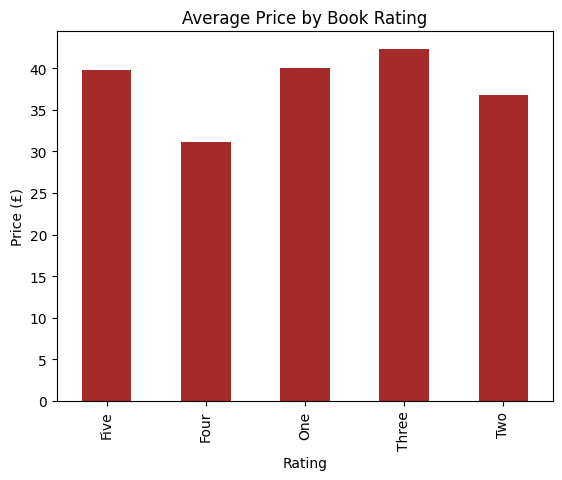

In [25]:
#Quick Plot in Colab

import matplotlib.pyplot as plt
summary['Avg_Price'].plot(kind='bar', color='brown', title='Average Price by Book Rating')
plt.ylabel('Price (£)')
plt.show()

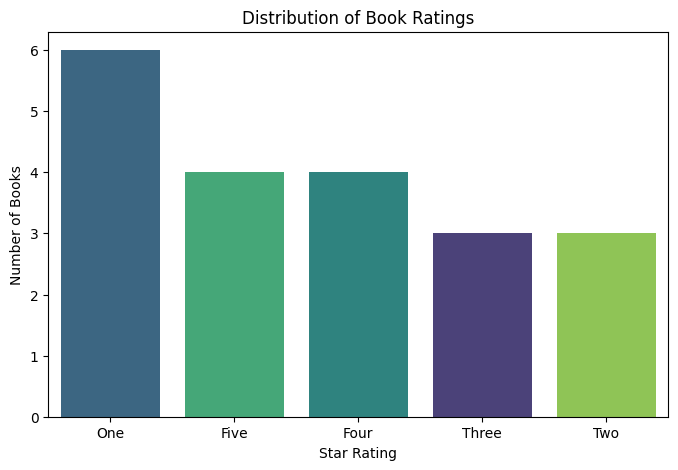

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Distribution of Book Ratings
plt.figure(figsize=(8, 5))
sns.countplot(x='Rating', data=df_scraped, palette='viridis', hue='Rating', legend=False, order=df_scraped['Rating'].value_counts().index)
plt.title('Distribution of Book Ratings')
plt.xlabel('Star Rating')
plt.ylabel('Number of Books')
plt.show()


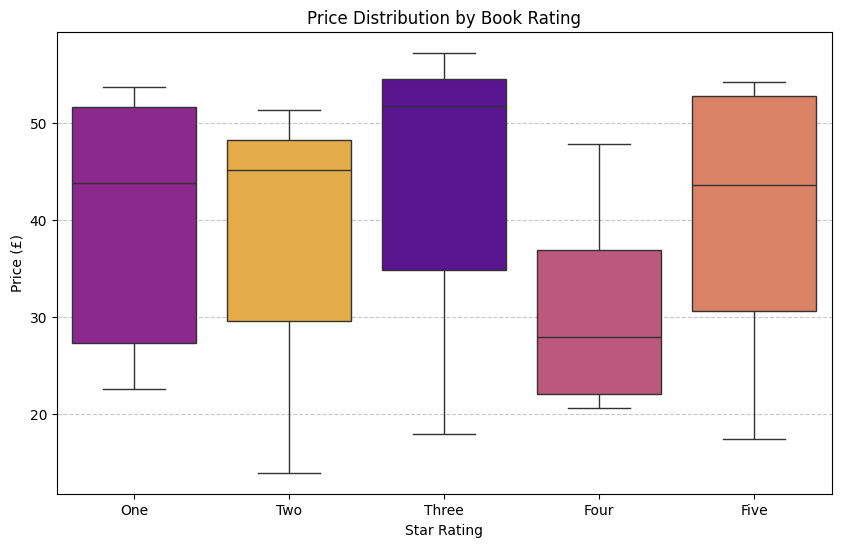

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Box Plot of Price Distribution by Rating
plt.figure(figsize=(10, 6))
sns.boxplot(x='Rating', y='Price_GBP', data=df_scraped, palette='plasma', hue='Rating', legend=False, order=['One', 'Two', 'Three', 'Four', 'Five'])
plt.title('Price Distribution by Book Rating')
plt.xlabel('Star Rating')
plt.ylabel('Price (£)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


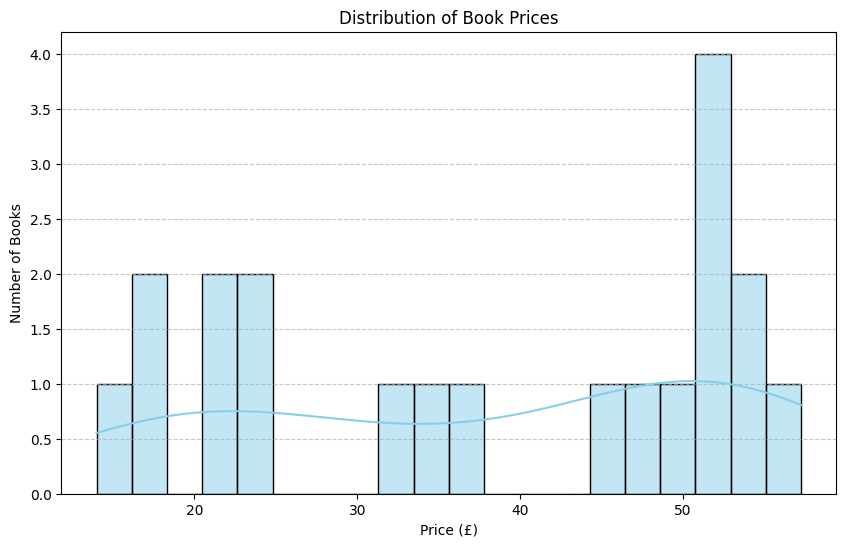

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Histogram of Price Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df_scraped['Price_GBP'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Book Prices')
plt.xlabel('Price (£)')
plt.ylabel('Number of Books')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


This histogram illustrates the frequency distribution of book prices in GBP. The 'kde' (Kernel Density Estimate) line provides a smoothed representation of the distribution, helping to identify peaks and general shape.

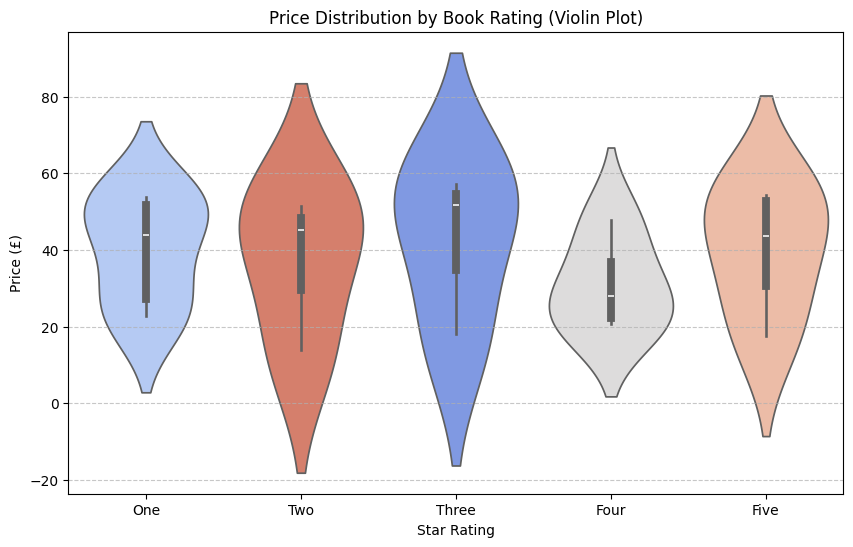

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# 4. Violin Plot of Price Distribution by Rating
plt.figure(figsize=(10, 6))
sns.violinplot(x='Rating', y='Price_GBP', data=df_scraped, palette='coolwarm', order=['One', 'Two', 'Three', 'Four', 'Five'], hue='Rating', legend=False)
plt.title('Price Distribution by Book Rating (Violin Plot)')
plt.xlabel('Star Rating')
plt.ylabel('Price (£)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


The violin plot offers a richer display than a simple box plot by showing the density of the price distribution within each rating category. The wider sections indicate a higher concentration of books at that price point.

This box plot displays the distribution of prices for books within each star rating category. It allows us to see the median price, interquartile range, and any outliers for each rating, offering a more detailed view than just the average price.

In [30]:
# Save to a multi-sheet Excel file
with pd.ExcelWriter('Market_Analysis_Report.xlsx') as writer:
    df_scraped.to_excel(writer, sheet_name='Raw_Scraped_Data', index=False)
    summary.to_excel(writer, sheet_name='Price_Analysis')

from google.colab import files
files.download('Market_Analysis_Report.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>